# Tutorial 1: Spatial Analysis of a Single Field of View

This tutorial demonstrates the core SpatialQuery workflow on a single spatial transcriptomics dataset.
We use a seqFISH mouse organogenesis (E8.5) embryo section containing 17,806 cells and 351 genes.
The analysis covers motif enrichment discovery, spatial visualization, differential expression between
motif-positive and motif-negative anchor cells, and cross-cell gene-gene covariation analysis.

**API class:** `spatial_query`

## 1. Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import anndata as ad
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from SpatialQuery import spatial_query

## 2. Load Data & Initialize SpatialQuery

In [3]:
DATA_DIR = "../data/mouse_organogenesis"

adata = ad.read_h5ad(f"{DATA_DIR}/embryo1.h5ad")
adata

AnnData object with n_obs × n_vars = 17806 × 351
    obs: 'embryo', 'pos', 'z', 'x_global', 'y_global', 'x_global_affine', 'y_global_affine', 'embryo_pos', 'embryo_pos_z', 'Area', 'UMAP1', 'UMAP2', 'celltype_mapped_refined', 'segmentation_vertices_x_global_affine', 'segmentation_vertices_y_global_affine'
    var: 'gene'
    uns: 'celltype_mapped_refined_colors'
    obsm: 'X_spatial', 'X_umap'

In [4]:
# ---- Configuration: adjust these to match your dataset ----
spatial_key = "X_spatial"
label_key = "celltype_mapped_refined"
feature_name = "gene"
dataset_name = "mouse_embryo1"

In [5]:
sp = spatial_query(
    adata=adata,
    dataset=dataset_name,
    spatial_key=spatial_key,
    label_key=label_key,
    feature_name=feature_name,
    build_gene_index=False,       # use adata.X directly for gene expression
    if_lognorm=True,              # log-normalize raw counts
    if_normalize_spatial_coord=True,
)


Auto-normalizing spatial coordinates: mean nearest neighbor distance = 1.0
Scale factor: 51.7200
build_gene_index is False. Using adata.X for gene expression analysis.
Log normalizing the expression data... If data is already log normalized, please set if_lognorm to False.


## 3. Visualize the Field of View

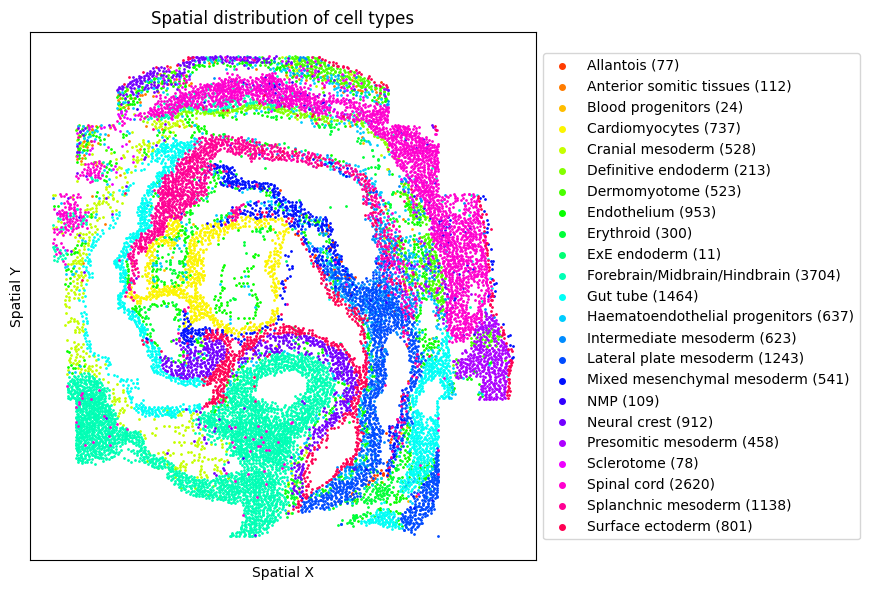

In [6]:
sp.plot_fov(min_cells_label=0, figsize=(8, 6))

## 4. Motif Enrichment Across Cell Types and Radii

A spatial motif is a recurring combination of cell types found in the neighborhood of an anchor cell type.
Here we scan all cell types as anchors across a range of radii to get an overview of spatial organization complexity.

In [7]:
radius_range = list(range(2, 21, 2))
unique_cts = sp.labels.unique().tolist()

enrich_radius_ct = dict()

for ct in unique_cts:
    enrich_radius_ct[ct] = []

    for r in radius_range:
        enrich_tmp = sp.motif_enrichment_dist(
            ct=ct,
            max_dist=r,
            min_support=0.5,
        )
        enrich_tmp = enrich_tmp[enrich_tmp['if_significant']]
        enrich_radius_ct[ct].append(enrich_tmp.shape[0])


Text(0.5, 1.0, 'Enriched motifs across radii')

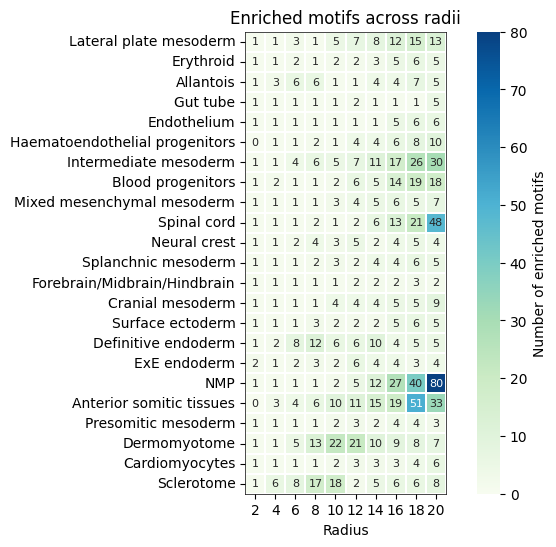

In [8]:
enrich_radius_ct_df = pd.DataFrame(enrich_radius_ct, index=radius_range)


fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(enrich_radius_ct_df.T, 
            cmap='GnBu', 
            linewidths=0.1, 
            square=True, annot=True, fmt='g', 
            annot_kws={'fontsize': 8}, ax=ax, linecolor='white',
            cbar_kws={'label': 'Number of enriched motifs'}
            )
for spine_name, spine in ax.spines.items():
    spine.set_visible(True)  
    spine.set_color('black') 
    spine.set_linewidth(0.5)
plt.xlabel('Radius')
plt.xticks(rotation=0)
plt.title('Enriched motifs across radii')



## 5. Targeted Motif Enrichment

We select **Gut tube** as the anchor cell type and discover which cell type combinations
are significantly enriched in its neighborhood within a radius of 8 (normalized units).

In [9]:
anchor_ct = 'Gut tube'
max_dist = 8
min_support = 0.2

enrich = sp.motif_enrichment_dist(
    ct=anchor_ct,
    max_dist=max_dist,
    min_support=min_support
)

enrich

,center,motifs,n_center_motif,n_center,n_motif,expectation,p-values,adj-pval,if_significant
0,Gut tube,"[Endothelium, Gut tube, Haematoendothelial pro...",748,1464,2439,200.533303,1.260625e-290,7.563750e-290,True
1,Gut tube,"[Cranial mesoderm, Gut tube]",357,1464,1282,105.405369,4.065308e-107,1.219592e-106,True
2,Gut tube,"[Endothelium, Gut tube, Splanchnic mesoderm]",320,1464,1188,97.676738,7.788483e-91,1.557697e-90,True
3,Gut tube,"[Gut tube, Haematoendothelial progenitors, Spl...",332,1464,1433,117.820510,1.252217e-75,1.878326e-75,True
4,Gut tube,"[Gut tube, Lateral plate mesoderm]",312,1464,1595,131.140065,1.212101e-52,1.454521e-52,True
5,Gut tube,"[Endothelium, Haematoendothelial progenitors, ...",293,1464,2863,235.394361,1.308209e-05,1.308209e-05,True


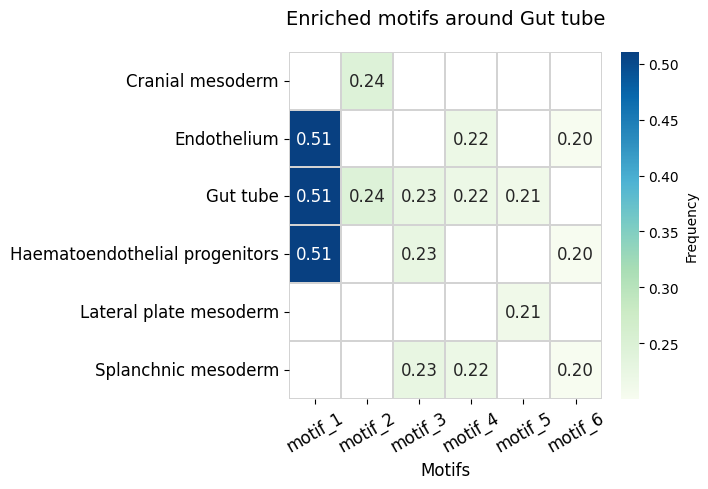

In [10]:
sp.plot_motif_enrichment_heatmap(
    enrich_df=enrich,
    figsize=(7, 5),
    title='Enriched motifs around Gut tube',   
)

## 6. Motif Enrichment Across Radii

For a specific motif of interest, we examine how enrichment significance and observed/expected ratio
change across radii 1–20.

In [11]:
p_vals = []
oe_ratio = []
ct = 'Gut tube'
motif = ['Splanchnic mesoderm', 'Endothelium']
radius_list = range(1, 21)

for i in radius_list:
    tt = sp.motif_enrichment_dist(
        ct=ct, 
        motifs=motif, 
        max_dist=i
    )
    p_vals.append(tt['p-values'][0])
    oe_ratio.append(tt['n_center_motif'][0]/tt['expectation'][0])

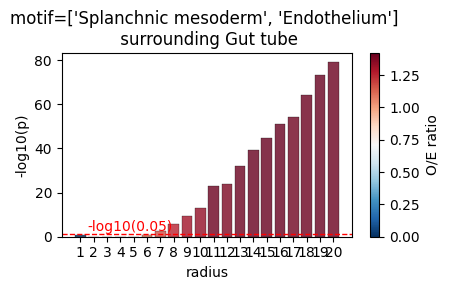

In [12]:
p_vals_df = pd.DataFrame({
    'radius': radius_list,
    '-log_pvals': -np.log10(p_vals),
    'O/E ratio': oe_ratio
})

fig, ax = plt.subplots(figsize=(4.5, 3))

cmap = plt.get_cmap('RdBu_r')
oe = p_vals_df['O/E ratio']
scaled = (oe - oe.min()) / (oe.max() - oe.min())
colors = [cmap(v) for v in scaled]

bars = ax.bar(p_vals_df['radius'].astype(str), 
              p_vals_df['-log_pvals'], 
              color=colors, edgecolor='black', alpha=0.8, linewidth=0.25)

sm = plt.cm.ScalarMappable(cmap=cmap)
sm.set_clim(oe.min(), oe.max())
plt.colorbar(sm, ax=ax, label='O/E ratio')

thr = -np.log10(0.05)
ax.axhline(thr, color='red', linestyle='--', linewidth=1)
ax.text(0.5, thr + 0.05, '-log10(0.05)', color='red', fontsize=10, va='bottom')

ax.set_ylabel('-log10(p)')
ax.set_xlabel('radius')
ax.set_title(f'motif={motif} \n surrounding {ct}')
plt.tight_layout()
plt.show()

## 7. Spatial Visualization of Motif

Visualize the spatial distribution of motif-positive anchor cells and their associated neighbor cells.

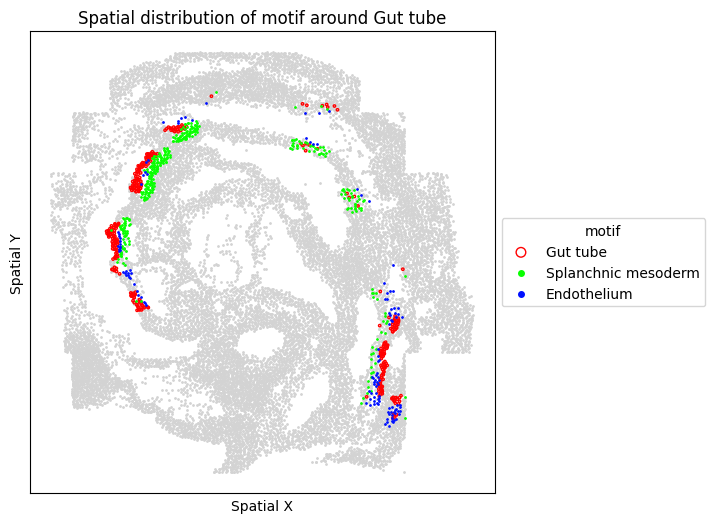

In [13]:
motif = ["Splanchnic mesoderm", "Endothelium"]

sp.plot_motif_celltype(
    ct=anchor_ct,
    motif=motif,
    max_dist=max_dist,
    figsize=(6, 6),
)

Alternatively, visualize motif-positive vs motif-negative anchor cells alongside motif-associated neighbor cells.

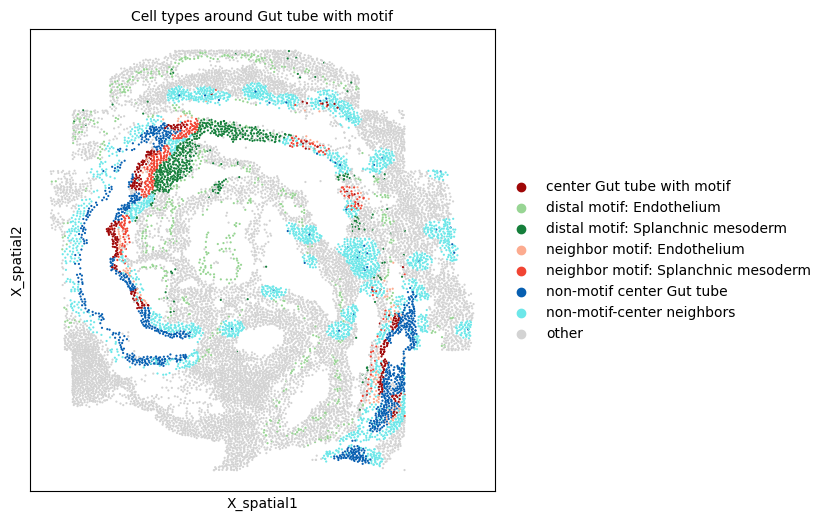

In [14]:
ids = sp.get_anchor_motif_cell_ids(
    ct=anchor_ct,
    motif=motif,
    max_dist=max_dist
)

sp.plot_all_center_motif(
    ct=anchor_ct,
    ids=ids, 
)

## 8. Differential Expression: Motif+ vs Motif− Anchor Cells

Compare gene expression between anchor cells that participate in the motif (motif+) and those that do not (motif−).
First, retrieve the cell IDs of motif-positive anchors, then run a t-test across all genes.

In [15]:
motif_enrich = sp.motif_enrichment_dist(
    ct=anchor_ct,
    motifs=motif,
    max_dist=max_dist,
    return_cellID=True
)
motif_enrich

,center,motifs,n_center_motif,n_center,n_motif,expectation,p-values,neighbor_id,center_id,if_significant
0,Gut tube,"[Endothelium, Splanchnic mesoderm]",322,1464,3117,256.278109,0.000002,"[6151, 6163, 6168, 6182, 6188, 14381, 6199, 62...","[529, 536, 537, 547, 550, 4493, 4611, 4613, 46...",True


In [16]:
center_id = motif_enrich['center_id'][0]
all_center_id = np.where(sp.labels == anchor_ct)[0]
non_center_id = np.setdiff1d(all_center_id, center_id)

de_genes = sp.de_genes(
    ind_group1=center_id,
    ind_group2=non_center_id,
    min_fraction=0.05,
    method='t-test',
    alpha=0.05    
)


Testing 351 genes ...


In [17]:
de_genes

,gene,proportion_1,proportion_2,abs_difference,log2fc,p_value,adj-pval,de_in
0,Dkk1,0.111801,0.243433,0.131631,-1.586187,8.074493e-14,1.778115e-11,group2
1,Wnt5a,0.319876,0.472855,0.152979,-1.045780,1.013171e-13,1.778115e-11,group2
2,Osr1,0.652174,0.464974,0.187200,0.943958,2.715462e-12,3.177090e-10,group1
3,T,0.161491,0.260946,0.099455,-1.527118,6.675586e-12,5.857827e-10,group2
4,Meis1,0.503106,0.345009,0.158097,0.959926,1.492688e-09,1.047867e-07,group1
...,...,...,...,...,...,...,...,...
75,Ldhb,0.521739,0.443082,0.078657,0.346249,8.586833e-03,3.965761e-02,group1
76,Pou5f1,0.074534,0.132224,0.057690,-0.778253,8.711626e-03,3.971144e-02,group2
77,Slc4a1,0.071429,0.138354,0.066925,-0.749696,9.692000e-03,4.361400e-02,group2
78,Setd1a,0.723602,0.685639,0.037963,0.261399,1.023892e-02,4.549189e-02,group1


## 9. Cross-cell Gene-Gene Covariation

Identify gene pairs where one gene is expressed in the anchor cell and the other in a neighboring motif cell,
and their expression levels are significantly correlated — specifically in the spatial context of this motif.

In [18]:
covarying_genes_by_type = sp.compute_gene_gene_correlation_by_type(
    ct=anchor_ct,
    motif=motif,
    max_dist=max_dist,
)

covarying_genes_by_type = covarying_genes_by_type[covarying_genes_by_type['if_significant']]

Computing covarying genes using expression data...
Analyzing 2 non-center cell types in motif: ['Splanchnic mesoderm', 'Endothelium']
After filtering (min_nonzero=10): 351 genes

Computing Correlation-3: Center without motif vs Neighbors
Unique center cells: 1106
Unique neighbor cells: 2851
... (55 lines omitted) ...

Results prepared and sorted


In [19]:
covarying_genes_by_type

,cell_type,gene_center,gene_motif,corr_neighbor,corr_non_neighbor,p_value_test1,delta_corr_test1,corr_center_no_motif,p_value_test2,delta_corr_test2,combined_score,q_value_test1,q_value_test2,reject_test1_fdr,reject_test2_fdr,abs_combined_score,if_significant
0,Splanchnic mesoderm,Sp5,Tbx5,0.696998,-0.004279,0.000000e+00,0.701277,0.076782,0.000000,0.620216,193.360220,0.000000,0.000000,True,True,193.360220,True
1,Splanchnic mesoderm,Nkx2-3,Tagln,0.576550,-0.006229,0.000000e+00,0.582779,-0.047309,0.000000,0.623860,183.460727,0.000000,0.000000,True,True,183.460727,True
2,Splanchnic mesoderm,Hoxb1,Tbx1,0.606402,-0.030189,0.000000e+00,0.636591,0.063244,0.000000,0.543158,171.356423,0.000000,0.000000,True,True,171.356423,True
3,Splanchnic mesoderm,Sp5,Wnt2,0.596063,0.000067,0.000000e+00,0.595996,0.150484,0.000000,0.445579,147.211285,0.000000,0.000000,True,True,147.211285,True
4,Splanchnic mesoderm,Tbx3,Tagln,0.395296,-0.000074,1.286408e-07,0.395370,-0.165390,0.000000,0.560686,118.561425,0.000158,0.000000,True,True,118.561425,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
771,Splanchnic mesoderm,Hoxb9,Meox1,0.289525,0.000234,1.691007e-04,0.289292,0.045858,0.000073,0.243667,1.032991,0.047793,0.025269,True,True,1.032991,True
772,Splanchnic mesoderm,Gata3,Hapln1,0.289761,-0.004068,1.341177e-04,0.293829,0.047934,0.000082,0.241827,1.032853,0.040498,0.027817,True,True,1.032853,True
848,Splanchnic mesoderm,Podxl,Ezh2,-0.292342,0.004740,1.120631e-04,-0.297082,-0.060807,0.000157,-0.231535,-0.968453,0.035351,0.045551,True,True,0.968453,True
852,Splanchnic mesoderm,Col1a2,Msx2,0.302228,0.004728,1.043428e-04,0.297501,0.072039,0.000162,0.230189,0.966198,0.033499,0.046536,True,True,0.966198,True


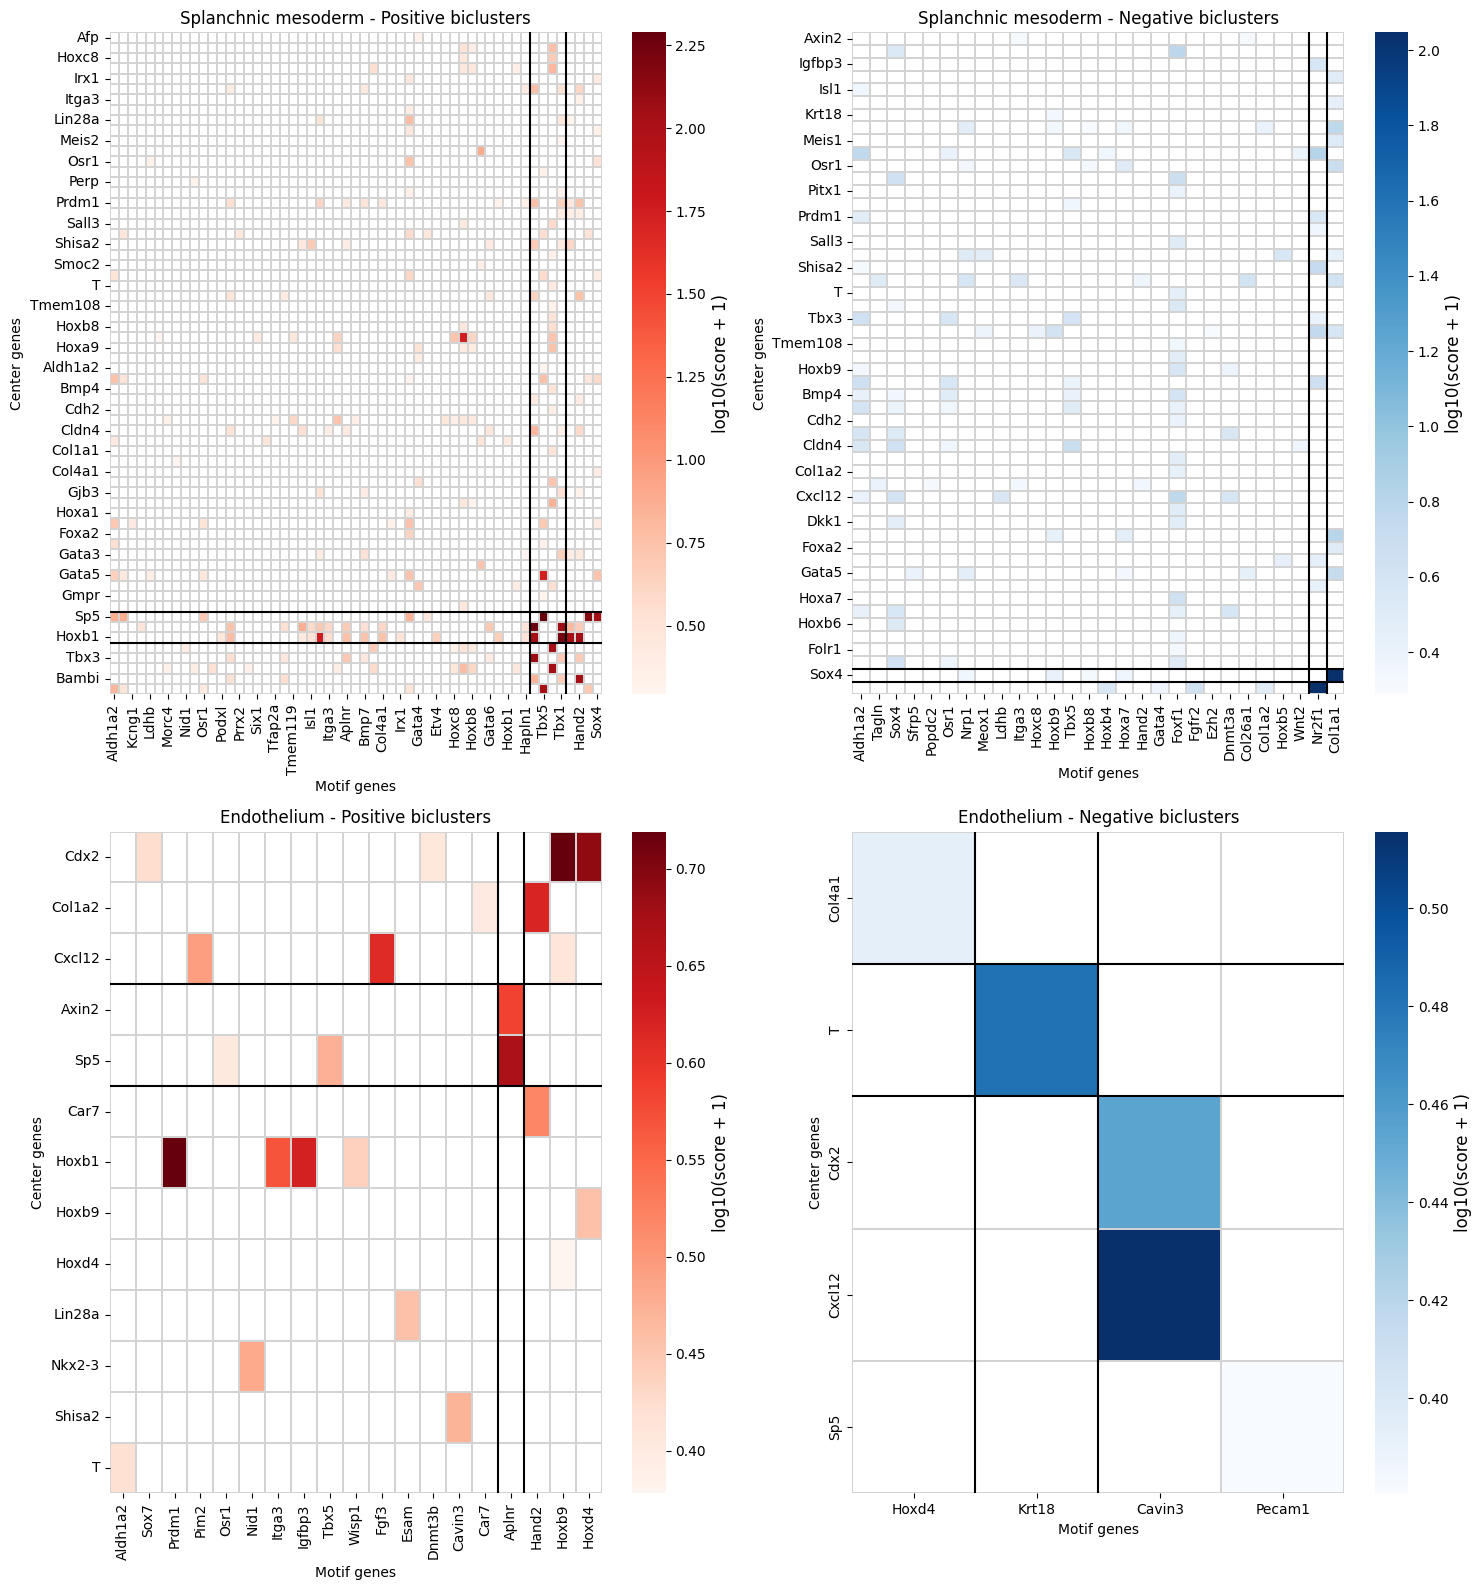

In [20]:
covarying_genes_module = sp.plot_gene_pair_heatmap(
    gene_pair_df=covarying_genes_by_type,
    figsize=(15, 8)
)

In [21]:
covarying_genes_module

,gene_center,gene_motif,combined_score,cluster_type,cluster_row,cluster_col,cell_type
0,Afp,Gata4,1.131970,positive,0,0,Splanchnic mesoderm
1,Akr1c19,Gata4,1.507798,positive,0,0,Splanchnic mesoderm
2,Aldh1a2,Tbx5,1.037975,positive,0,1,Splanchnic mesoderm
3,Axin2,Aldh1a2,4.586966,positive,0,0,Splanchnic mesoderm
4,Axin2,Foxf1,1.081744,positive,0,0,Splanchnic mesoderm
...,...,...,...,...,...,...,...
406,Cdx2,Cavin3,-1.846188,negative,2,2,Endothelium
407,Col4a1,Hoxd4,-1.471384,negative,0,0,Endothelium
408,Cxcl12,Cavin3,-2.278150,negative,2,2,Endothelium
409,Sp5,Pecam1,-1.402200,negative,2,2,Endothelium
